# Import Libraries

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import time

import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import display

# File and API Configuration

This cell defines input files, output folders, and common API settings. Study dates are not set here because they must come from FluNet.

In [2]:
FLUNET_DATA_PATH = Path("dataset/flunet_japan_analysis_ready.csv")

OPENMETEO_DIR = Path("dataset/openmeteo")
RAW_DIR = OPENMETEO_DIR / "raw"

LOCATIONS_PATH = OPENMETEO_DIR / "locations_master.csv"
COMBINED_PATH = OPENMETEO_DIR / "openmeteo_daily_japan.csv"
AUDIT_PATH = OPENMETEO_DIR / "openmeteo_daily_audit_summary.csv"
MANIFEST_PATH = OPENMETEO_DIR / "openmeteo_download_manifest.csv"

GEOCODING_URL = "https://geocoding-api.open-meteo.com/v1/search"
HISTORICAL_WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"

MODEL = "ERA5-Land"
MODEL_API_VALUE = "era5_land"
TIMEZONE = "Asia/Tokyo"
TEMPERATURE_UNIT = "celsius"
DAILY_VARIABLES = [
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
]

OPENMETEO_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Load FluNet Analysis-Ready Dataset

The weather period is matched to the available FluNet study period. The source CSV is read without modification.

In [3]:
df_flunet = pd.read_csv(FLUNET_DATA_PATH)

print(f"Shape: {df_flunet.shape[0]:,} rows × {df_flunet.shape[1]} columns")
print("Columns:")
print(df_flunet.columns.tolist())

assert "ISO_WEEKSTARTDATE" in df_flunet.columns
df_flunet["ISO_WEEKSTARTDATE"] = pd.to_datetime(
    df_flunet["ISO_WEEKSTARTDATE"]
)

df_flunet.head()

Shape: 1,522 rows × 19 columns
Columns:
['WHOREGION', 'COUNTRY_CODE', 'COUNTRY_AREA_TERRITORY', 'ISO2', 'HEMISPHERE', 'FLUSEASON', 'ORIGIN_SOURCE', 'ISO_WEEKSTARTDATE', 'ISO_YEAR', 'ISO_WEEK', 'ISOYW', 'INF_A', 'INF_B', 'INF_ALL', 'SPEC_PROCESSED_NB', 'INF_NEGATIVE', 'positive_specimen_count', 'positive_count_source', 'positivity_rate_percent']


,WHOREGION,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2,HEMISPHERE,FLUSEASON,ORIGIN_SOURCE,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,ISOYW,INF_A,INF_B,INF_ALL,SPEC_PROCESSED_NB,INF_NEGATIVE,positive_specimen_count,positive_count_source,positivity_rate_percent
0,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-07,1996,41,199641,1.0,0.0,1.0,NaN,NaN,1.0,INF_ALL,NaN
1,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-14,1996,42,199642,2.0,0.0,2.0,NaN,NaN,2.0,INF_ALL,NaN
2,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-21,1996,43,199643,1.0,0.0,1.0,NaN,NaN,1.0,INF_ALL,NaN
3,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-28,1996,44,199644,4.0,0.0,4.0,NaN,NaN,4.0,INF_ALL,NaN
4,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-04,1996,45,199645,11.0,0.0,11.0,NaN,NaN,11.0,INF_ALL,NaN


# Determine Weather Date Range from FluNet

FluNet uses ISO weeks from Monday to Sunday. Daily weather data must include every day in the first and last FluNet weeks.

In [4]:
FLUNET_START_DATE = df_flunet["ISO_WEEKSTARTDATE"].min()
FLUNET_LAST_WEEK_START = df_flunet["ISO_WEEKSTARTDATE"].max()

WEATHER_START_DATE = FLUNET_START_DATE
WEATHER_END_DATE = FLUNET_LAST_WEEK_START + pd.Timedelta(days=6)

date_range_summary = pd.DataFrame({
    "Item": [
        "First FluNet week start",
        "Last FluNet week start",
        "Weather start date",
        "Weather end date",
    ],
    "Date": [
        FLUNET_START_DATE.date(),
        FLUNET_LAST_WEEK_START.date(),
        WEATHER_START_DATE.date(),
        WEATHER_END_DATE.date(),
    ],
})
date_range_summary

,Item,Date
0,First FluNet week start,1996-10-07
1,Last FluNet week start,2026-08-03
2,Weather start date,1996-10-07
3,Weather end date,2026-08-09


In [5]:
flunet_period_summary = pd.DataFrame([{
    "FluNet weekly records": len(df_flunet),
    "Minimum ISO year": df_flunet["ISO_YEAR"].min(),
    "Maximum ISO year": df_flunet["ISO_YEAR"].max(),
    "Minimum ISO week": df_flunet["ISO_WEEK"].min(),
    "Maximum ISO week": df_flunet["ISO_WEEK"].max(),
}])
flunet_period_summary

,FluNet weekly records,Minimum ISO year,Maximum ISO year,Minimum ISO week,Maximum ISO week
0,1522,1996,2026,1,53


# Stage 1 — Define and Verify Locations

The first stage selects locations and checks their coordinates before weather data are requested.

## 1. Selected Locations

Ten locations represent different geographic areas of Japan. These locations provide geographic coverage; they do not create prefecture-level influenza data.

In [6]:
selected_locations = pd.DataFrame([
    {"region": "Hokkaido", "location": "Sapporo", "expected_admin1": "Hokkaido"},
    {"region": "Tohoku", "location": "Sendai", "expected_admin1": "Miyagi"},
    {"region": "Kanto", "location": "Tokyo", "expected_admin1": "Tokyo"},
    {"region": "Japan Sea / Hokuriku", "location": "Niigata", "expected_admin1": "Niigata"},
    {"region": "Chubu", "location": "Nagoya", "expected_admin1": "Aichi"},
    {"region": "Kansai", "location": "Osaka", "expected_admin1": "Osaka"},
    {"region": "Chugoku", "location": "Hiroshima", "expected_admin1": "Hiroshima"},
    {"region": "Shikoku", "location": "Takamatsu", "expected_admin1": "Kagawa"},
    {"region": "Kyushu", "location": "Fukuoka", "expected_admin1": "Fukuoka"},
    {"region": "Subtropical South", "location": "Naha", "expected_admin1": "Okinawa"},
])
selected_locations

,region,location,expected_admin1
0,Hokkaido,Sapporo,Hokkaido
1,Tohoku,Sendai,Miyagi
2,Kanto,Tokyo,Tokyo
3,Japan Sea / Hokuriku,Niigata,Niigata
4,Chubu,Nagoya,Aichi
5,Kansai,Osaka,Osaka
6,Chugoku,Hiroshima,Hiroshima
7,Shikoku,Takamatsu,Kagawa
8,Kyushu,Fukuoka,Fukuoka
9,Subtropical South,Naha,Okinawa


## 2. Resolve Coordinates with Open-Meteo Geocoding

Open-Meteo needs latitude and longitude. Each search is limited to Japan, and the selected result must match the expected prefecture or administrative area.

In [7]:
resolved_rows = []

for location_row in selected_locations.itertuples(index=False):
    geocoding_params = {
        "name": location_row.location,
        "countryCode": "JP",
        "count": 10,
        "language": "en",
        "format": "json",
    }
    response = requests.get(GEOCODING_URL, params=geocoding_params, timeout=60)
    response.raise_for_status()
    results = response.json().get("results", [])

    japan_results = [
        result for result in results
        if result.get("country_code") == "JP"
    ]
    matching_results = [
        result for result in japan_results
        if result.get("admin1") == location_row.expected_admin1
    ]
    selected_result = matching_results[0] if matching_results else japan_results[0]

    resolved_rows.append({
        "region": location_row.region,
        "location": location_row.location,
        "expected_admin1": location_row.expected_admin1,
        "admin1": selected_result.get("admin1"),
        "country": selected_result.get("country"),
        "country_code": selected_result.get("country_code"),
        "latitude": selected_result.get("latitude"),
        "longitude": selected_result.get("longitude"),
        "elevation": selected_result.get("elevation"),
        "timezone": selected_result.get("timezone"),
        "geocoding_id": selected_result.get("id"),
    })

df_locations = pd.DataFrame(resolved_rows)

## 3. Review Resolved Locations

The resolved administrative area must match the expected value. Mismatches are displayed and must be reviewed before downloading weather data.

In [8]:
df_locations["admin1_match"] = (
    df_locations["admin1"] == df_locations["expected_admin1"]
)

display(df_locations[[
    "region", "location", "admin1", "latitude", "longitude",
    "elevation", "timezone", "admin1_match",
]])

location_mismatches = df_locations.loc[~df_locations["admin1_match"]]
print(f"Location mismatches: {len(location_mismatches)}")
display(location_mismatches)

assert df_locations["admin1_match"].all()

,region,location,admin1,latitude,longitude,elevation,timezone,admin1_match
0,Hokkaido,Sapporo,Hokkaido,43.06667,141.35000,26.0,Asia/Tokyo,True
1,Tohoku,Sendai,Miyagi,38.26667,140.86667,53.0,Asia/Tokyo,True
2,Kanto,Tokyo,Tokyo,35.68950,139.69171,44.0,Asia/Tokyo,True
3,Japan Sea / Hokuriku,Niigata,Niigata,37.92259,139.04124,1.0,Asia/Tokyo,True
4,Chubu,Nagoya,Aichi,35.18147,136.90640,23.0,Asia/Tokyo,True
5,Kansai,Osaka,Osaka,34.69379,135.50107,4.0,Asia/Tokyo,True
6,Chugoku,Hiroshima,Hiroshima,34.40000,132.45000,16.0,Asia/Tokyo,True
7,Shikoku,Takamatsu,Kagawa,34.33333,134.05000,17.0,Asia/Tokyo,True
8,Kyushu,Fukuoka,Fukuoka,33.60000,130.41667,3.0,Asia/Tokyo,True
9,Subtropical South,Naha,Okinawa,26.21300,127.67851,1.0,Asia/Tokyo,True


Location mismatches: 0


,region,location,expected_admin1,admin1,country,country_code,latitude,longitude,elevation,timezone,geocoding_id,admin1_match


## 4. Save Location Master File

The verified coordinates are saved once and reused for every weather request.

In [9]:
location_master_columns = [
    "region", "location", "admin1", "country", "country_code",
    "latitude", "longitude", "elevation", "timezone", "geocoding_id",
]
locations_master = df_locations[location_master_columns].copy()
locations_master.to_csv(LOCATIONS_PATH, index=False)
locations_master

,region,location,admin1,country,country_code,latitude,longitude,elevation,timezone,geocoding_id
0,Hokkaido,Sapporo,Hokkaido,Japan,JP,43.06667,141.35000,26.0,Asia/Tokyo,2128295
1,Tohoku,Sendai,Miyagi,Japan,JP,38.26667,140.86667,53.0,Asia/Tokyo,2111149
2,Kanto,Tokyo,Tokyo,Japan,JP,35.68950,139.69171,44.0,Asia/Tokyo,1850147
3,Japan Sea / Hokuriku,Niigata,Niigata,Japan,JP,37.92259,139.04124,1.0,Asia/Tokyo,1855431
4,Chubu,Nagoya,Aichi,Japan,JP,35.18147,136.90640,23.0,Asia/Tokyo,1856057
5,Kansai,Osaka,Osaka,Japan,JP,34.69379,135.50107,4.0,Asia/Tokyo,1853909
6,Chugoku,Hiroshima,Hiroshima,Japan,JP,34.40000,132.45000,16.0,Asia/Tokyo,1862415
7,Shikoku,Takamatsu,Kagawa,Japan,JP,34.33333,134.05000,17.0,Asia/Tokyo,1851100
8,Kyushu,Fukuoka,Fukuoka,Japan,JP,33.60000,130.41667,3.0,Asia/Tokyo,1863967
9,Subtropical South,Naha,Okinawa,Japan,JP,26.21300,127.67851,1.0,Asia/Tokyo,1856035


# Stage 2 — Download Raw Daily Weather Data

The second stage downloads daily temperature data with identical settings for every location.

## 1. Historical Weather Request Configuration

All requests use ERA5-Land, Asia/Tokyo, Celsius, and the FluNet-derived date range. Only daily mean, minimum, and maximum 2 m temperature are requested.

In [10]:
weather_request_settings = pd.DataFrame([{
    "Model": MODEL,
    "Start date": WEATHER_START_DATE.date(),
    "End date": WEATHER_END_DATE.date(),
    "Timezone": TIMEZONE,
    "Temperature unit": TEMPERATURE_UNIT,
    "Daily variables": ", ".join(DAILY_VARIABLES),
}])
weather_request_settings

,Model,Start date,End date,Timezone,Temperature unit,Daily variables
0,ERA5-Land,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe..."


## 2. Test Download with Sapporo

Sapporo is downloaded first. This confirms that the request settings and output structure work before all locations are processed.

In [11]:
sapporo = locations_master.loc[
    locations_master["location"] == "Sapporo"
].iloc[0]

SAPPORO_RAW_PATH = RAW_DIR / "sapporo_daily.csv"

if SAPPORO_RAW_PATH.exists():
    cached_sapporo = pd.read_csv(SAPPORO_RAW_PATH, parse_dates=["date"])
    cache_matches_period = (
        cached_sapporo["date"].min() == WEATHER_START_DATE
        and cached_sapporo["date"].max() == WEATHER_END_DATE
    )
else:
    cache_matches_period = False

if cache_matches_period:
    df_sapporo = cached_sapporo
else:
    sapporo_params = {
        "latitude": sapporo["latitude"],
        "longitude": sapporo["longitude"],
        "start_date": WEATHER_START_DATE.strftime("%Y-%m-%d"),
        "end_date": WEATHER_END_DATE.strftime("%Y-%m-%d"),
        "daily": ",".join(DAILY_VARIABLES),
        "timezone": TIMEZONE,
        "temperature_unit": TEMPERATURE_UNIT,
        "models": MODEL_API_VALUE,
    }

    response = requests.get(
        HISTORICAL_WEATHER_URL, params=sapporo_params, timeout=180
    )
    response.raise_for_status()
    sapporo_json = response.json()

    df_sapporo = pd.DataFrame(sapporo_json["daily"])
    df_sapporo["date"] = pd.to_datetime(df_sapporo["time"])
    df_sapporo = df_sapporo.drop(columns="time")

    df_sapporo.insert(1, "region", sapporo["region"])
    df_sapporo.insert(2, "location", sapporo["location"])
    df_sapporo.insert(3, "admin1", sapporo["admin1"])
    df_sapporo.insert(4, "latitude", sapporo["latitude"])
    df_sapporo.insert(5, "longitude", sapporo["longitude"])
    df_sapporo.insert(6, "elevation", sapporo["elevation"])
    df_sapporo.insert(7, "timezone", TIMEZONE)

print(f"Shape: {df_sapporo.shape}")
display(df_sapporo.head(10))
display(df_sapporo.tail(10))

Shape: (10899, 11)


,temperature_2m_mean,region,location,admin1,latitude,longitude,elevation,timezone,temperature_2m_min,temperature_2m_max,date
0,13.7,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,9.7,16.3,1996-10-07
1,11.1,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,8.0,14.6,1996-10-08
2,10.8,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,7.7,13.7,1996-10-09
3,10.7,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,8.3,13.8,1996-10-10
4,12.1,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,8.4,16.0,1996-10-11
5,11.6,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,6.2,16.8,1996-10-12
6,12.8,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,8.8,16.9,1996-10-13
7,12.2,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,7.7,16.8,1996-10-14
8,10.8,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,7.6,14.0,1996-10-15
9,7.2,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,5.5,9.1,1996-10-16


,temperature_2m_mean,region,location,admin1,latitude,longitude,elevation,timezone,temperature_2m_min,temperature_2m_max,date
10889,19.3,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,17.9,21.1,2026-07-31
10890,19.1,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,16.7,21.7,2026-08-01
10891,20.0,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,15.8,24.6,2026-08-02
10892,19.8,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,16.0,24.4,2026-08-03
10893,19.2,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,16.2,23.1,2026-08-04
10894,20.2,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,16.1,24.6,2026-08-05
10895,21.9,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,17.0,26.9,2026-08-06
10896,24.2,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,19.5,29.8,2026-08-07
10897,21.7,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,19.0,24.4,2026-08-08
10898,20.4,Hokkaido,Sapporo,Hokkaido,43.06667,141.35,26.0,Asia/Tokyo,17.5,23.8,2026-08-09


## 3. Audit the Sapporo Test Download

This check confirms that Sapporo covers the full required period and has a valid daily structure.

In [12]:
expected_days = (WEATHER_END_DATE - WEATHER_START_DATE).days + 1

sapporo_audit = pd.DataFrame([{
    "Expected start date": WEATHER_START_DATE.date(),
    "Observed start date": df_sapporo["date"].min().date(),
    "Expected end date": WEATHER_END_DATE.date(),
    "Observed end date": df_sapporo["date"].max().date(),
    "Expected days": expected_days,
    "Rows": len(df_sapporo),
    "Unique dates": df_sapporo["date"].nunique(),
    "Duplicate dates": df_sapporo.duplicated("date").sum(),
    "Missing mean": df_sapporo["temperature_2m_mean"].isna().sum(),
    "Missing min": df_sapporo["temperature_2m_min"].isna().sum(),
    "Missing max": df_sapporo["temperature_2m_max"].isna().sum(),
}])
sapporo_audit

,Expected start date,Observed start date,Expected end date,Observed end date,Expected days,Rows,Unique dates,Duplicate dates,Missing mean,Missing min,Missing max
0,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0


In [13]:
sapporo_temperature_range = pd.DataFrame({
    "Minimum": df_sapporo[DAILY_VARIABLES].min(),
    "Maximum": df_sapporo[DAILY_VARIABLES].max(),
})
sapporo_temperature_range

,Minimum,Maximum
temperature_2m_mean,-14.3,27.7
temperature_2m_min,-18.9,25.3
temperature_2m_max,-11.5,32.2


## 4. Save Sapporo Raw Data

The test result is saved at daily resolution. No weekly or national variables are added.

In [14]:
df_sapporo.to_csv(SAPPORO_RAW_PATH, index=False)
print(SAPPORO_RAW_PATH)

dataset/openmeteo/raw/sapporo_daily.csv


## 5. Download All Selected Locations

The same request is applied to every verified location. Each result is saved as a separate raw daily CSV with the same schema.

In [15]:
download_records = []

for location_row in locations_master.itertuples(index=False):
    raw_path = RAW_DIR / f"{location_row.location.lower()}_daily.csv"

    if raw_path.exists():
        existing_daily = pd.read_csv(raw_path, parse_dates=["date"])
        file_matches_period = (
            existing_daily["date"].min() == WEATHER_START_DATE
            and existing_daily["date"].max() == WEATHER_END_DATE
        )
    else:
        file_matches_period = False

    request_params = {
        "latitude": location_row.latitude,
        "longitude": location_row.longitude,
        "start_date": WEATHER_START_DATE.strftime("%Y-%m-%d"),
        "end_date": WEATHER_END_DATE.strftime("%Y-%m-%d"),
        "daily": ",".join(DAILY_VARIABLES),
        "timezone": TIMEZONE,
        "temperature_unit": TEMPERATURE_UNIT,
        "models": MODEL_API_VALUE,
    }

    if not file_matches_period:
        response = requests.get(
            HISTORICAL_WEATHER_URL, params=request_params, timeout=180
        )
        if response.status_code == 429:
            time.sleep(60)
            response = requests.get(
                HISTORICAL_WEATHER_URL, params=request_params, timeout=180
            )
        response.raise_for_status()
        weather_json = response.json()

        location_daily = pd.DataFrame(weather_json["daily"])
        location_daily["date"] = pd.to_datetime(location_daily["time"])
        location_daily = location_daily.drop(columns="time")

        location_daily.insert(1, "region", location_row.region)
        location_daily.insert(2, "location", location_row.location)
        location_daily.insert(3, "admin1", location_row.admin1)
        location_daily.insert(4, "latitude", location_row.latitude)
        location_daily.insert(5, "longitude", location_row.longitude)
        location_daily.insert(6, "elevation", location_row.elevation)
        location_daily.insert(7, "timezone", TIMEZONE)
        location_daily.to_csv(raw_path, index=False)
        time.sleep(15)

    download_records.append({
        "location": location_row.location,
        "region": location_row.region,
        "latitude": location_row.latitude,
        "longitude": location_row.longitude,
        "model": MODEL,
        "flunet_source_file": str(FLUNET_DATA_PATH),
        "flunet_first_week_start": FLUNET_START_DATE.date(),
        "flunet_last_week_start": FLUNET_LAST_WEEK_START.date(),
        "weather_start_date": WEATHER_START_DATE.date(),
        "weather_end_date": WEATHER_END_DATE.date(),
        "timezone": TIMEZONE,
        "temperature_unit": TEMPERATURE_UNIT,
        "daily_variables": ", ".join(DAILY_VARIABLES),
        "downloaded_at": datetime.now(timezone.utc).isoformat(),
        "raw_file": str(raw_path),
    })

download_manifest = pd.DataFrame(download_records)
download_manifest[["location", "raw_file"]]

,location,raw_file
0,Sapporo,dataset/openmeteo/raw/sapporo_daily.csv
1,Sendai,dataset/openmeteo/raw/sendai_daily.csv
2,Tokyo,dataset/openmeteo/raw/tokyo_daily.csv
3,Niigata,dataset/openmeteo/raw/niigata_daily.csv
4,Nagoya,dataset/openmeteo/raw/nagoya_daily.csv
5,Osaka,dataset/openmeteo/raw/osaka_daily.csv
6,Hiroshima,dataset/openmeteo/raw/hiroshima_daily.csv
7,Takamatsu,dataset/openmeteo/raw/takamatsu_daily.csv
8,Fukuoka,dataset/openmeteo/raw/fukuoka_daily.csv
9,Naha,dataset/openmeteo/raw/naha_daily.csv


## 6. Raw CSV Schema

Every raw location file uses the same long-format daily schema.

| Column | Meaning |
| --- | --- |
| `date` | Local calendar date |
| `region` | Geographic area represented |
| `location` | Selected city |
| `admin1` | Prefecture-level administrative area |
| `latitude` | Requested latitude |
| `longitude` | Requested longitude |
| `elevation` | Location elevation in metres |
| `timezone` | Local timezone |
| `temperature_2m_mean` | Daily mean air temperature at 2 m |
| `temperature_2m_min` | Daily minimum air temperature at 2 m |
| `temperature_2m_max` | Daily maximum air temperature at 2 m |

## 7. Create Download Manifest

The manifest records the data source, request settings, download time, and raw file for each location. It does not change the weather data.

In [16]:
download_manifest.to_csv(MANIFEST_PATH, index=False)
download_manifest

,location,region,latitude,longitude,model,flunet_source_file,flunet_first_week_start,flunet_last_week_start,weather_start_date,weather_end_date,timezone,temperature_unit,daily_variables,downloaded_at,raw_file
0,Sapporo,Hokkaido,43.06667,141.35000,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.459235+00:00,dataset/openmeteo/raw/sapporo_daily.csv
1,Sendai,Tohoku,38.26667,140.86667,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.472157+00:00,dataset/openmeteo/raw/sendai_daily.csv
2,Tokyo,Kanto,35.68950,139.69171,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.484668+00:00,dataset/openmeteo/raw/tokyo_daily.csv
3,Niigata,Japan Sea / Hokuriku,37.92259,139.04124,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.497203+00:00,dataset/openmeteo/raw/niigata_daily.csv
4,Nagoya,Chubu,35.18147,136.90640,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.509541+00:00,dataset/openmeteo/raw/nagoya_daily.csv
5,Osaka,Kansai,34.69379,135.50107,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.523700+00:00,dataset/openmeteo/raw/osaka_daily.csv
6,Hiroshima,Chugoku,34.40000,132.45000,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.537709+00:00,dataset/openmeteo/raw/hiroshima_daily.csv
7,Takamatsu,Shikoku,34.33333,134.05000,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.550755+00:00,dataset/openmeteo/raw/takamatsu_daily.csv
8,Fukuoka,Kyushu,33.60000,130.41667,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.564106+00:00,dataset/openmeteo/raw/fukuoka_daily.csv
9,Naha,Subtropical South,26.21300,127.67851,ERA5-Land,dataset/flunet_japan_analysis_ready.csv,1996-10-07,2026-08-03,1996-10-07,2026-08-09,Asia/Tokyo,celsius,"temperature_2m_mean, temperature_2m_min, tempe...",2026-08-20T07:29:39.577842+00:00,dataset/openmeteo/raw/naha_daily.csv


# Stage 3 — Combine Raw Daily Data

The third stage combines the raw location files. No averaging or weekly conversion is performed.

## 1. Load All Raw Location Files

The ten raw CSV files must have the same columns before they are combined.

In [17]:
raw_files = [
    RAW_DIR / f"{location.lower()}_daily.csv"
    for location in locations_master["location"]
]
raw_dataframes = [pd.read_csv(path, parse_dates=["date"]) for path in raw_files]

reference_columns = raw_dataframes[0].columns.tolist()
same_schema = all(
    daily_data.columns.tolist() == reference_columns
    for daily_data in raw_dataframes
)
print(f"All raw files use the same schema: {same_schema}")
assert same_schema

df_weather_daily = pd.concat(raw_dataframes, ignore_index=True)

All raw files use the same schema: True


## 2. Combined Daily Dataset

One row represents one location on one date. The dataset stays in long format and retains the original daily values.

In [18]:
df_weather_daily = df_weather_daily.sort_values(
    ["date", "location"]
).reset_index(drop=True)

combined_overview = pd.DataFrame([{
    "Rows": len(df_weather_daily),
    "Columns": df_weather_daily.shape[1],
    "Locations": df_weather_daily["location"].nunique(),
    "Minimum date": df_weather_daily["date"].min().date(),
    "Maximum date": df_weather_daily["date"].max().date(),
    "Start date matches": df_weather_daily["date"].min() == WEATHER_START_DATE,
    "End date matches": df_weather_daily["date"].max() == WEATHER_END_DATE,
}])

display(combined_overview)
display(df_weather_daily.head(20))
display(df_weather_daily.tail(20))

,Rows,Columns,Locations,Minimum date,Maximum date,Start date matches,End date matches
0,108990,11,10,1996-10-07,2026-08-09,True,True


,temperature_2m_mean,region,location,admin1,latitude,longitude,elevation,timezone,temperature_2m_min,temperature_2m_max,date
0,18.2,Kyushu,Fukuoka,Fukuoka,33.60000,130.41667,3.0,Asia/Tokyo,16.0,20.7,1996-10-07
1,19.1,Chugoku,Hiroshima,Hiroshima,34.40000,132.45000,16.0,Asia/Tokyo,16.4,21.4,1996-10-07
2,20.0,Chubu,Nagoya,Aichi,35.18147,136.90640,23.0,Asia/Tokyo,16.2,24.3,1996-10-07
3,25.1,Subtropical South,Naha,Okinawa,26.21300,127.67851,1.0,Asia/Tokyo,23.7,26.3,1996-10-07
4,17.6,Japan Sea / Hokuriku,Niigata,Niigata,37.92259,139.04124,1.0,Asia/Tokyo,15.3,22.2,1996-10-07
5,19.8,Kansai,Osaka,Osaka,34.69379,135.50107,4.0,Asia/Tokyo,16.5,25.2,1996-10-07
6,13.7,Hokkaido,Sapporo,Hokkaido,43.06667,141.35000,26.0,Asia/Tokyo,9.7,16.3,1996-10-07
7,17.5,Tohoku,Sendai,Miyagi,38.26667,140.86667,53.0,Asia/Tokyo,14.8,21.6,1996-10-07
8,20.3,Shikoku,Takamatsu,Kagawa,34.33333,134.05000,17.0,Asia/Tokyo,18.1,25.0,1996-10-07
9,21.0,Kanto,Tokyo,Tokyo,35.68950,139.69171,44.0,Asia/Tokyo,17.8,25.6,1996-10-07


,temperature_2m_mean,region,location,admin1,latitude,longitude,elevation,timezone,temperature_2m_min,temperature_2m_max,date
108970,30.2,Kyushu,Fukuoka,Fukuoka,33.60000,130.41667,3.0,Asia/Tokyo,27.3,34.7,2026-08-08
108971,30.0,Chugoku,Hiroshima,Hiroshima,34.40000,132.45000,16.0,Asia/Tokyo,26.1,34.0,2026-08-08
108972,29.2,Chubu,Nagoya,Aichi,35.18147,136.90640,23.0,Asia/Tokyo,26.0,33.7,2026-08-08
108973,28.3,Subtropical South,Naha,Okinawa,26.21300,127.67851,1.0,Asia/Tokyo,27.6,29.1,2026-08-08
108974,27.5,Japan Sea / Hokuriku,Niigata,Niigata,37.92259,139.04124,1.0,Asia/Tokyo,25.5,30.7,2026-08-08
108975,30.0,Kansai,Osaka,Osaka,34.69379,135.50107,4.0,Asia/Tokyo,25.6,35.0,2026-08-08
108976,21.7,Hokkaido,Sapporo,Hokkaido,43.06667,141.35000,26.0,Asia/Tokyo,19.0,24.4,2026-08-08
108977,25.9,Tohoku,Sendai,Miyagi,38.26667,140.86667,53.0,Asia/Tokyo,24.1,29.2,2026-08-08
108978,28.6,Shikoku,Takamatsu,Kagawa,34.33333,134.05000,17.0,Asia/Tokyo,26.2,31.5,2026-08-08
108979,27.7,Kanto,Tokyo,Tokyo,35.68950,139.69171,44.0,Asia/Tokyo,25.1,31.1,2026-08-08


## 3. Save Combined Raw Dataset

The combined file keeps one location-date observation per row. Temperature values are not changed.

In [19]:
df_weather_daily.to_csv(COMBINED_PATH, index=False)
print(COMBINED_PATH)

dataset/openmeteo/openmeteo_daily_japan.csv


# Stage 4 — Audit Raw Daily Weather Data

The final stage checks dates, duplicates, missing values, and basic temperature structure.

## 1. Daily Coverage by Location

This table checks whether all locations cover the same daily period and whether the temperature fields are complete.

In [20]:
daily_coverage = df_weather_daily.groupby(
    ["region", "location"], as_index=False
).agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    total_rows=("date", "size"),
    unique_dates=("date", "nunique"),
    missing_mean=("temperature_2m_mean", lambda values: values.isna().sum()),
    missing_min=("temperature_2m_min", lambda values: values.isna().sum()),
    missing_max=("temperature_2m_max", lambda values: values.isna().sum()),
)

duplicate_counts = (
    df_weather_daily.duplicated(["location", "date"], keep=False)
    .groupby(df_weather_daily["location"])
    .sum()
)
daily_coverage["duplicate_dates"] = (
    daily_coverage["location"].map(duplicate_counts).fillna(0).astype(int)
)
daily_coverage

,region,location,start_date,end_date,total_rows,unique_dates,missing_mean,missing_min,missing_max,duplicate_dates
0,Chubu,Nagoya,1996-10-07,2026-08-09,10899,10899,0,0,0,0
1,Chugoku,Hiroshima,1996-10-07,2026-08-09,10899,10899,0,0,0,0
2,Hokkaido,Sapporo,1996-10-07,2026-08-09,10899,10899,0,0,0,0
3,Japan Sea / Hokuriku,Niigata,1996-10-07,2026-08-09,10899,10899,0,0,0,0
4,Kansai,Osaka,1996-10-07,2026-08-09,10899,10899,0,0,0,0
5,Kanto,Tokyo,1996-10-07,2026-08-09,10899,10899,0,0,0,0
6,Kyushu,Fukuoka,1996-10-07,2026-08-09,10899,10899,0,0,0,0
7,Shikoku,Takamatsu,1996-10-07,2026-08-09,10899,10899,0,0,0,0
8,Subtropical South,Naha,1996-10-07,2026-08-09,10899,10899,0,0,0,0
9,Tohoku,Sendai,1996-10-07,2026-08-09,10899,10899,0,0,0,0


## 2. Check Expected Calendar Coverage

The expected calendar comes from the FluNet-derived weather dates. Missing dates are counted but not filled.

In [21]:
expected_calendar = pd.date_range(WEATHER_START_DATE, WEATHER_END_DATE, freq="D")
calendar_checks = []
missing_date_rows = []

for location, location_data in df_weather_daily.groupby("location"):
    observed_dates = pd.DatetimeIndex(location_data["date"].drop_duplicates())
    missing_dates = expected_calendar.difference(observed_dates)

    calendar_checks.append({
        "location": location,
        "expected_days": len(expected_calendar),
        "observed_unique_days": len(observed_dates),
        "missing_dates": len(missing_dates),
    })

    for missing_date in missing_dates:
        missing_date_rows.append({
            "location": location,
            "missing_date": missing_date.date(),
        })

calendar_coverage = pd.DataFrame(calendar_checks)
missing_dates_detail = pd.DataFrame(missing_date_rows)

display(calendar_coverage)
print(f"Total missing location-dates: {len(missing_dates_detail)}")
display(missing_dates_detail)

,location,expected_days,observed_unique_days,missing_dates
0,Fukuoka,10899,10899,0
1,Hiroshima,10899,10899,0
2,Nagoya,10899,10899,0
3,Naha,10899,10899,0
4,Niigata,10899,10899,0
5,Osaka,10899,10899,0
6,Sapporo,10899,10899,0
7,Sendai,10899,10899,0
8,Takamatsu,10899,10899,0
9,Tokyo,10899,10899,0


Total missing location-dates: 0


""


## 3. Check Duplicate Dates

Each location should have only one row per date. Duplicate rows are reported and are not removed automatically.

In [22]:
duplicate_mask = df_weather_daily.duplicated(
    ["location", "date"], keep=False
)
duplicate_rows = df_weather_daily.loc[duplicate_mask].sort_values(
    ["location", "date"]
)

duplicate_summary = (
    duplicate_rows.groupby("location")
    .size()
    .reindex(locations_master["location"], fill_value=0)
    .rename("duplicate_rows")
    .to_frame()
)

display(duplicate_summary)
display(duplicate_rows)

,duplicate_rows
location,
Sapporo,0
Sendai,0
Tokyo,0
Niigata,0
Nagoya,0
Osaka,0
Hiroshima,0
Takamatsu,0
Fukuoka,0


,temperature_2m_mean,region,location,admin1,latitude,longitude,elevation,timezone,temperature_2m_min,temperature_2m_max,date


## 4. Temperature Value Check

Minimum, maximum, and missing values are reported for each location. We also check that daily minimum ≤ mean ≤ maximum. Unusual values are not changed.

In [23]:
temperature_value_checks = df_weather_daily.groupby("location")[
    DAILY_VARIABLES
].agg(["min", "max", lambda values: values.isna().sum()])
temperature_value_checks = temperature_value_checks.rename(
    columns={"<lambda_0>": "missing"}
)
temperature_value_checks

temperature_2m_mean               temperature_2m_min                \
                          min   max missing                min   max missing   
location                                                                       
Fukuoka                  -2.4  32.4       0               -3.8  28.9       0   
Hiroshima                -2.6  31.8       0               -4.2  28.1       0   
Nagoya                   -2.4  32.0       0               -8.9  28.1       0   
Naha                     10.6  30.3       0                9.1  29.5       0   
Niigata                  -3.8  31.0       0               -7.9  27.9       0   
Osaka                    -1.5  31.9       0               -4.8  28.7       0   
Sapporo                 -14.3  27.7       0              -18.9  25.3       0   
Sendai                   -7.5  28.9       0              -14.4  25.8       0   
Takamatsu                -1.6  30.4       0               -2.6  27.7       0   
Tokyo                    -4.8  31.9       0              -10.5  28.0       0   

          temperature_2m_max                
                         min   max missing  
location                                    
Fukuoka                 -1.1  38.0       0  
Hiroshima               -1.0  37.3       0  
Nagoya                   0.8  38.4       0  
Naha                    12.3  31.8       0  
Niigata                 -2.9  35.7       0  
Osaka                    0.8  37.8       0  
Sapporo                -11.5  32.2       0  
Sendai                  -3.5  33.3       0  
Takamatsu                0.2  33.8       0  
Tokyo                    0.5  36.9       0

In [24]:
temperature_order_violation = ~(
    (df_weather_daily["temperature_2m_min"] <= df_weather_daily["temperature_2m_mean"])
    & (df_weather_daily["temperature_2m_mean"] <= df_weather_daily["temperature_2m_max"])
)
temperature_order_violation &= df_weather_daily[DAILY_VARIABLES].notna().all(axis=1)

order_violations_by_location = (
    temperature_order_violation.groupby(df_weather_daily["location"])
    .sum()
    .rename("temperature_order_violations")
    .to_frame()
)
order_violations_by_location

,temperature_order_violations
location,
Fukuoka,0
Hiroshima,0
Nagoya,0
Naha,0
Niigata,0
Osaka,0
Sapporo,0
Sendai,0
Takamatsu,0


## 5. Create Daily Audit Summary

The audit summary keeps one row per location and records the main coverage and quality checks.

In [25]:
audit_rows = []

for location_row in locations_master.itertuples(index=False):
    location_data = df_weather_daily.loc[
        df_weather_daily["location"] == location_row.location
    ]
    observed_dates = pd.DatetimeIndex(location_data["date"].drop_duplicates())

    audit_rows.append({
        "region": location_row.region,
        "location": location_row.location,
        "expected_start_date": WEATHER_START_DATE.date(),
        "observed_start_date": location_data["date"].min().date(),
        "expected_end_date": WEATHER_END_DATE.date(),
        "observed_end_date": location_data["date"].max().date(),
        "expected_days": len(expected_calendar),
        "total_rows": len(location_data),
        "unique_dates": location_data["date"].nunique(),
        "missing_dates": len(expected_calendar.difference(observed_dates)),
        "duplicate_dates": location_data.duplicated("date", keep=False).sum(),
        "missing_mean": location_data["temperature_2m_mean"].isna().sum(),
        "missing_min": location_data["temperature_2m_min"].isna().sum(),
        "missing_max": location_data["temperature_2m_max"].isna().sum(),
        "min_temperature": location_data["temperature_2m_min"].min(),
        "max_temperature": location_data["temperature_2m_max"].max(),
        "temperature_order_violations": temperature_order_violation.loc[
            location_data.index
        ].sum(),
    })

daily_audit_summary = pd.DataFrame(audit_rows)
daily_audit_summary.to_csv(AUDIT_PATH, index=False)
daily_audit_summary

,region,location,expected_start_date,observed_start_date,expected_end_date,observed_end_date,expected_days,total_rows,unique_dates,missing_dates,duplicate_dates,missing_mean,missing_min,missing_max,min_temperature,max_temperature,temperature_order_violations
0,Hokkaido,Sapporo,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-18.9,32.2,0
1,Tohoku,Sendai,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-14.4,33.3,0
2,Kanto,Tokyo,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-10.5,36.9,0
3,Japan Sea / Hokuriku,Niigata,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-7.9,35.7,0
4,Chubu,Nagoya,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-8.9,38.4,0
5,Kansai,Osaka,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-4.8,37.8,0
6,Chugoku,Hiroshima,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-4.2,37.3,0
7,Shikoku,Takamatsu,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-2.6,33.8,0
8,Kyushu,Fukuoka,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,-3.8,38.0,0
9,Subtropical South,Naha,1996-10-07,1996-10-07,2026-08-09,2026-08-09,10899,10899,10899,0,0,0,0,0,9.1,31.8,0


## 6. Simple Raw Data Preview

This plot is a visual check of Sapporo daily mean temperature. It does not use smoothing, weekly aggregation, or FluNet data.

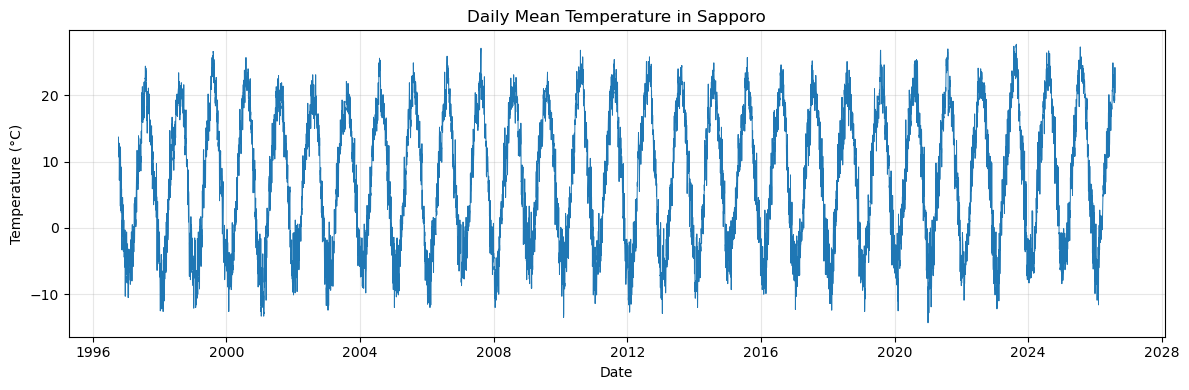

In [26]:
sapporo_plot_data = df_weather_daily.loc[
    df_weather_daily["location"] == "Sapporo"
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    sapporo_plot_data["date"],
    sapporo_plot_data["temperature_2m_mean"],
    linewidth=0.7,
)
ax.set_title("Daily Mean Temperature in Sapporo")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Data Collection Summary

- The weather period was determined automatically from the FluNet analysis-ready dataset.
- Ten locations were selected across Japan, and their administrative areas were verified.
- Daily ERA5-Land mean, minimum, and maximum 2 m temperatures were downloaded in Celsius using Asia/Tokyo time.
- One raw CSV was preserved for each location.
- The raw files were combined into one long-format daily dataset without averaging.
- Calendar coverage, duplicates, missing values, and temperature order were checked.
- No influenza–temperature relationship was analyzed.

In [27]:
collection_period_summary = pd.DataFrame({
    "Item": [
        "FluNet first week start",
        "FluNet last week start",
        "Weather start date",
        "Weather end date",
    ],
    "Date": [
        FLUNET_START_DATE.date(),
        FLUNET_LAST_WEEK_START.date(),
        WEATHER_START_DATE.date(),
        WEATHER_END_DATE.date(),
    ],
})

collection_result_summary = pd.DataFrame([{
    "Locations": df_weather_daily["location"].nunique(),
    "Daily rows": len(df_weather_daily),
    "Missing location-dates": daily_audit_summary["missing_dates"].sum(),
    "Duplicate rows": daily_audit_summary["duplicate_dates"].sum(),
    "Missing temperature values": daily_audit_summary[
        ["missing_mean", "missing_min", "missing_max"]
    ].sum().sum(),
    "Temperature order violations": daily_audit_summary[
        "temperature_order_violations"
    ].sum(),
}])

display(collection_period_summary)
display(collection_result_summary)

,Item,Date
0,FluNet first week start,1996-10-07
1,FluNet last week start,2026-08-03
2,Weather start date,1996-10-07
3,Weather end date,2026-08-09


,Locations,Daily rows,Missing location-dates,Duplicate rows,Missing temperature values,Temperature order violations
0,10,108990,0,0,0,0


# Stage 5 — Convert Daily Weather to ISO Weeks

Daily records are converted to the same Monday–Sunday ISO week structure used by FluNet.

## 1. Prepare Daily Weather for Weekly Aggregation

Daily weather data are converted to the same ISO week system used by FluNet. The original daily DataFrame is not changed.

In [28]:
df_weather_weekly_source = df_weather_daily.copy()
df_weather_weekly_source["date"] = pd.to_datetime(
    df_weather_weekly_source["date"]
)

iso_calendar = df_weather_weekly_source["date"].dt.isocalendar()
df_weather_weekly_source["ISO_YEAR"] = iso_calendar["year"].astype(int)
df_weather_weekly_source["ISO_WEEK"] = iso_calendar["week"].astype(int)
df_weather_weekly_source["ISO_WEEKSTARTDATE"] = (
    df_weather_weekly_source["date"]
    - pd.to_timedelta(df_weather_weekly_source["date"].dt.weekday, unit="D")
)

## 2. Check ISO Week Mapping

This check confirms that each date is assigned to the correct Monday-based ISO week. Dates near New Year are included because ISO year may differ from calendar year.

In [29]:
new_year_sample = df_weather_weekly_source.loc[
    (
        (df_weather_weekly_source["date"].dt.month == 12)
        & (df_weather_weekly_source["date"].dt.day >= 29)
    )
    | (
        (df_weather_weekly_source["date"].dt.month == 1)
        & (df_weather_weekly_source["date"].dt.day <= 4)
    ),
    ["date", "location", "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE"],
]

new_year_sample.loc[
    new_year_sample["location"] == "Tokyo"
].head(20)

,date,location,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE
839,1996-12-29,Tokyo,1996,52,1996-12-23
849,1996-12-30,Tokyo,1997,1,1996-12-30
859,1996-12-31,Tokyo,1997,1,1996-12-30
869,1997-01-01,Tokyo,1997,1,1996-12-30
879,1997-01-02,Tokyo,1997,1,1996-12-30
889,1997-01-03,Tokyo,1997,1,1996-12-30
899,1997-01-04,Tokyo,1997,1,1996-12-30
4489,1997-12-29,Tokyo,1998,1,1997-12-29
4499,1997-12-30,Tokyo,1998,1,1997-12-29
4509,1997-12-31,Tokyo,1998,1,1997-12-29


## 3. Aggregate Daily Temperature by Location and Week

One row is created for each location and ISO week. Weekly mean uses daily mean temperature. Weekly minimum and maximum use the lowest daily minimum and highest daily maximum.

In [30]:
weekly_group_columns = [
    "location", "region", "admin1", "latitude", "longitude",
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
]

df_weather_weekly = (
    df_weather_weekly_source.groupby(weekly_group_columns, as_index=False)
    .agg(
        daily_records=("date", "size"),
        unique_daily_dates=("date", "nunique"),
        weekly_mean_temperature=("temperature_2m_mean", "mean"),
        weekly_min_temperature=("temperature_2m_min", "min"),
        weekly_max_temperature=("temperature_2m_max", "max"),
        mean_temperature_available_days=("temperature_2m_mean", "count"),
        min_temperature_available_days=("temperature_2m_min", "count"),
        max_temperature_available_days=("temperature_2m_max", "count"),
    )
)

## 4. Apply Complete-Week Rule

Weekly temperature is valid only when all seven dates and all seven values for each temperature variable are available. Incomplete values remain missing and are not interpolated.

In [31]:
df_weather_weekly["complete_week"] = (
    df_weather_weekly["unique_daily_dates"].eq(7)
    & df_weather_weekly["mean_temperature_available_days"].eq(7)
    & df_weather_weekly["min_temperature_available_days"].eq(7)
    & df_weather_weekly["max_temperature_available_days"].eq(7)
)

weekly_temperature_columns = [
    "weekly_mean_temperature",
    "weekly_min_temperature",
    "weekly_max_temperature",
]
df_weather_weekly.loc[
    ~df_weather_weekly["complete_week"], weekly_temperature_columns
] = pd.NA

## 5. Review Weekly-by-Location Dataset

The weekly dataset is sorted by week and location. Coverage columns are retained so each weekly value can be audited.

In [32]:
weekly_output_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
    "region", "location", "admin1", "latitude", "longitude",
    "daily_records", "unique_daily_dates",
    "mean_temperature_available_days",
    "min_temperature_available_days",
    "max_temperature_available_days",
    "weekly_mean_temperature",
    "weekly_min_temperature",
    "weekly_max_temperature",
    "complete_week",
]

df_weather_weekly = df_weather_weekly[weekly_output_columns].sort_values(
    ["ISO_WEEKSTARTDATE", "location"]
).reset_index(drop=True)

weekly_dataset_overview = pd.DataFrame([{
    "Rows": len(df_weather_weekly),
    "Columns": df_weather_weekly.shape[1],
    "Locations": df_weather_weekly["location"].nunique(),
    "Minimum week start": df_weather_weekly["ISO_WEEKSTARTDATE"].min(),
    "Maximum week start": df_weather_weekly["ISO_WEEKSTARTDATE"].max(),
}])

display(weekly_dataset_overview)
display(df_weather_weekly.head(20))
display(df_weather_weekly.tail(20))

,Rows,Columns,Locations,Minimum week start,Maximum week start
0,15570,17,10,1996-10-07,2026-08-03


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,region,location,admin1,latitude,longitude,daily_records,unique_daily_dates,mean_temperature_available_days,min_temperature_available_days,max_temperature_available_days,weekly_mean_temperature,weekly_min_temperature,weekly_max_temperature,complete_week
0,1996,41,1996-10-07,Kyushu,Fukuoka,Fukuoka,33.60000,130.41667,7,7,7,7,7,17.771429,12.5,24.4,True
1,1996,41,1996-10-07,Chugoku,Hiroshima,Hiroshima,34.40000,132.45000,7,7,7,7,7,17.300000,10.5,23.6,True
2,1996,41,1996-10-07,Chubu,Nagoya,Aichi,35.18147,136.90640,7,7,7,7,7,17.357143,10.6,24.3,True
3,1996,41,1996-10-07,Subtropical South,Naha,Okinawa,26.21300,127.67851,7,7,7,7,7,25.100000,22.0,26.6,True
4,1996,41,1996-10-07,Japan Sea / Hokuriku,Niigata,Niigata,37.92259,139.04124,7,7,7,7,7,16.142857,10.0,22.2,True
5,1996,41,1996-10-07,Kansai,Osaka,Osaka,34.69379,135.50107,7,7,7,7,7,17.728571,11.8,25.2,True
6,1996,41,1996-10-07,Hokkaido,Sapporo,Hokkaido,43.06667,141.35000,7,7,7,7,7,11.828571,6.2,16.9,True
7,1996,41,1996-10-07,Tohoku,Sendai,Miyagi,38.26667,140.86667,7,7,7,7,7,14.842857,8.4,21.6,True
8,1996,41,1996-10-07,Shikoku,Takamatsu,Kagawa,34.33333,134.05000,7,7,7,7,7,18.714286,14.1,25.0,True
9,1996,41,1996-10-07,Kanto,Tokyo,Tokyo,35.68950,139.69171,7,7,7,7,7,17.185714,13.5,25.6,True


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,region,location,admin1,latitude,longitude,daily_records,unique_daily_dates,mean_temperature_available_days,min_temperature_available_days,max_temperature_available_days,weekly_mean_temperature,weekly_min_temperature,weekly_max_temperature,complete_week
15550,2026,31,2026-07-27,Kyushu,Fukuoka,Fukuoka,33.60000,130.41667,7,7,7,7,7,29.814286,25.7,35.1,True
15551,2026,31,2026-07-27,Chugoku,Hiroshima,Hiroshima,34.40000,132.45000,7,7,7,7,7,29.828571,23.1,37.3,True
15552,2026,31,2026-07-27,Chubu,Nagoya,Aichi,35.18147,136.90640,7,7,7,7,7,29.371429,23.8,38.4,True
15553,2026,31,2026-07-27,Subtropical South,Naha,Okinawa,26.21300,127.67851,7,7,7,7,7,29.257143,26.1,31.2,True
15554,2026,31,2026-07-27,Japan Sea / Hokuriku,Niigata,Niigata,37.92259,139.04124,7,7,7,7,7,25.700000,22.6,29.3,True
15555,2026,31,2026-07-27,Kansai,Osaka,Osaka,34.69379,135.50107,7,7,7,7,7,29.942857,24.7,36.2,True
15556,2026,31,2026-07-27,Hokkaido,Sapporo,Hokkaido,43.06667,141.35000,7,7,7,7,7,19.557143,15.8,24.6,True
15557,2026,31,2026-07-27,Tohoku,Sendai,Miyagi,38.26667,140.86667,7,7,7,7,7,22.928571,19.8,27.9,True
15558,2026,31,2026-07-27,Shikoku,Takamatsu,Kagawa,34.33333,134.05000,7,7,7,7,7,29.457143,25.8,33.3,True
15559,2026,31,2026-07-27,Kanto,Tokyo,Tokyo,35.68950,139.69171,7,7,7,7,7,28.014286,22.5,34.9,True


## 6. Save Weekly-by-Location Dataset

Each saved row represents one location and one ISO week. No national proxy is included yet.

In [33]:
WEEKLY_LOCATION_PATH = OPENMETEO_DIR / "openmeteo_weekly_by_location.csv"
df_weather_weekly.to_csv(WEEKLY_LOCATION_PATH, index=False)
print(WEEKLY_LOCATION_PATH)

dataset/openmeteo/openmeteo_weekly_by_location.csv


# Stage 6 — Audit Weekly Weather Data

Weekly data are checked for coverage, missing weeks, duplicates, and basic temperature order.

## 1. Weekly Coverage by Location

This table checks whether every location has complete weekly weather data.

In [34]:
weekly_coverage_by_location = df_weather_weekly.groupby(
    ["region", "location"], as_index=False
).agg(
    total_weeks=("ISO_WEEKSTARTDATE", "size"),
    complete_weeks=("complete_week", "sum"),
    first_week=("ISO_WEEKSTARTDATE", "min"),
    last_week=("ISO_WEEKSTARTDATE", "max"),
    missing_weekly_mean=("weekly_mean_temperature", lambda values: values.isna().sum()),
    missing_weekly_min=("weekly_min_temperature", lambda values: values.isna().sum()),
    missing_weekly_max=("weekly_max_temperature", lambda values: values.isna().sum()),
)
weekly_coverage_by_location["incomplete_weeks"] = (
    weekly_coverage_by_location["total_weeks"]
    - weekly_coverage_by_location["complete_weeks"]
)
weekly_coverage_by_location["coverage_percent"] = (
    weekly_coverage_by_location["complete_weeks"]
    / weekly_coverage_by_location["total_weeks"] * 100
).round(2)

weekly_coverage_by_location

,region,location,total_weeks,complete_weeks,first_week,last_week,missing_weekly_mean,missing_weekly_min,missing_weekly_max,incomplete_weeks,coverage_percent
0,Chubu,Nagoya,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
1,Chugoku,Hiroshima,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
2,Hokkaido,Sapporo,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
3,Japan Sea / Hokuriku,Niigata,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
4,Kansai,Osaka,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
5,Kanto,Tokyo,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
6,Kyushu,Fukuoka,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
7,Shikoku,Takamatsu,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
8,Subtropical South,Naha,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0
9,Tohoku,Sendai,1557,1557,1996-10-07,2026-08-03,0,0,0,0,100.0


## 2. Check Expected FluNet Weeks

Every weather location is compared with the unique FluNet week list. Missing and extra weeks are reported but not removed.

In [35]:
expected_flunet_weeks = (
    df_flunet[["ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE"]]
    .drop_duplicates()
    .sort_values("ISO_WEEKSTARTDATE")
    .reset_index(drop=True)
)
expected_week_dates = set(expected_flunet_weeks["ISO_WEEKSTARTDATE"])

week_comparison_rows = []
missing_flunet_week_rows = []
extra_weather_week_rows = []

for location, location_data in df_weather_weekly.groupby("location"):
    observed_week_dates = set(location_data["ISO_WEEKSTARTDATE"])
    missing_dates = sorted(expected_week_dates - observed_week_dates)
    extra_dates = sorted(observed_week_dates - expected_week_dates)

    week_comparison_rows.append({
        "location": location,
        "expected_flunet_weeks": len(expected_week_dates),
        "observed_weather_weeks": len(observed_week_dates),
        "missing_flunet_weeks": len(missing_dates),
        "extra_weather_weeks": len(extra_dates),
    })
    missing_flunet_week_rows.extend(
        {"location": location, "ISO_WEEKSTARTDATE": date}
        for date in missing_dates
    )
    extra_weather_week_rows.extend(
        {"location": location, "ISO_WEEKSTARTDATE": date}
        for date in extra_dates
    )

weekly_flu_comparison = pd.DataFrame(week_comparison_rows)
missing_flunet_weeks_detail = pd.DataFrame(missing_flunet_week_rows)
extra_weather_weeks_detail = pd.DataFrame(extra_weather_week_rows)

display(weekly_flu_comparison)
print(f"Missing FluNet location-weeks: {len(missing_flunet_weeks_detail)}")
print(f"Extra weather location-weeks: {len(extra_weather_weeks_detail)}")

,location,expected_flunet_weeks,observed_weather_weeks,missing_flunet_weeks,extra_weather_weeks
0,Fukuoka,1522,1557,0,35
1,Hiroshima,1522,1557,0,35
2,Nagoya,1522,1557,0,35
3,Naha,1522,1557,0,35
4,Niigata,1522,1557,0,35
5,Osaka,1522,1557,0,35
6,Sapporo,1522,1557,0,35
7,Sendai,1522,1557,0,35
8,Takamatsu,1522,1557,0,35
9,Tokyo,1522,1557,0,35


Missing FluNet location-weeks: 0
Extra weather location-weeks: 350


## 3. Inspect Incomplete Weeks

Incomplete weeks are displayed without filling or interpolation.

In [36]:
incomplete_week_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE", "location",
    "daily_records", "unique_daily_dates",
    "mean_temperature_available_days",
    "min_temperature_available_days",
    "max_temperature_available_days",
]
incomplete_weeks = df_weather_weekly.loc[
    ~df_weather_weekly["complete_week"], incomplete_week_columns
]

if incomplete_weeks.empty:
    print("All location-weeks contain complete seven-day temperature data.")
else:
    display(incomplete_weeks)

All location-weeks contain complete seven-day temperature data.


## 4. Check Duplicate Location-Weeks

Each location should have one row per ISO week. Duplicates are reported and not removed automatically.

In [37]:
duplicate_location_week_mask = df_weather_weekly.duplicated(
    ["location", "ISO_WEEKSTARTDATE"], keep=False
)
duplicate_location_weeks = df_weather_weekly.loc[
    duplicate_location_week_mask
].sort_values(["location", "ISO_WEEKSTARTDATE"])

print(f"Duplicated location-week rows: {len(duplicate_location_weeks)}")
display(duplicate_location_weeks)

Duplicated location-week rows: 0


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,region,location,admin1,latitude,longitude,daily_records,unique_daily_dates,mean_temperature_available_days,min_temperature_available_days,max_temperature_available_days,weekly_mean_temperature,weekly_min_temperature,weekly_max_temperature,complete_week


## 5. Weekly Temperature Sanity Check

Simple ranges are reported for each location. Weekly minimum should not exceed weekly mean, and weekly mean should not exceed weekly maximum.

In [38]:
weekly_temperature_ranges = df_weather_weekly.groupby("location").agg(
    minimum_weekly_mean_temperature=("weekly_mean_temperature", "min"),
    maximum_weekly_mean_temperature=("weekly_mean_temperature", "max"),
    minimum_weekly_min_temperature=("weekly_min_temperature", "min"),
    maximum_weekly_max_temperature=("weekly_max_temperature", "max"),
)

weekly_temperature_order_violation = ~(
    (df_weather_weekly["weekly_min_temperature"] <= df_weather_weekly["weekly_mean_temperature"])
    & (df_weather_weekly["weekly_mean_temperature"] <= df_weather_weekly["weekly_max_temperature"])
)
weekly_temperature_order_violation &= df_weather_weekly[
    weekly_temperature_columns
].notna().all(axis=1)

weekly_order_violations = (
    weekly_temperature_order_violation.groupby(df_weather_weekly["location"])
    .sum()
    .rename("temperature_order_violations")
)

weekly_temperature_ranges.join(weekly_order_violations)

,minimum_weekly_mean_temperature,maximum_weekly_mean_temperature,minimum_weekly_min_temperature,maximum_weekly_max_temperature,temperature_order_violations
location,,,,,
Fukuoka,2.042857,31.171429,-3.8,38.0,0
Hiroshima,0.700000,30.157143,-4.2,37.3,0
Nagoya,-0.328571,30.657143,-8.9,38.4,0
Naha,13.957143,29.928571,9.1,31.8,0
Niigata,-1.371429,29.557143,-7.9,35.7,0
Osaka,0.800000,30.885714,-4.8,37.8,0
Sapporo,-11.057143,26.785714,-18.9,32.2,0
Sendai,-5.271429,28.085714,-14.4,33.3,0
Takamatsu,1.957143,29.457143,-2.6,33.8,0


## 6. Save Weekly Audit Summary

The audit summary keeps one row per location and records the main weekly quality checks.

In [39]:
weekly_audit_summary = (
    weekly_coverage_by_location.merge(
        weekly_flu_comparison, on="location", how="left"
    )
)
weekly_audit_summary["duplicate_location_weeks"] = (
    weekly_audit_summary["location"].map(
        duplicate_location_weeks.groupby("location").size()
    ).fillna(0).astype(int)
)
weekly_audit_summary["temperature_order_violations"] = (
    weekly_audit_summary["location"].map(weekly_order_violations).astype(int)
)

weekly_audit_columns = [
    "region", "location", "expected_flunet_weeks", "observed_weather_weeks",
    "complete_weeks", "incomplete_weeks", "coverage_percent",
    "missing_flunet_weeks", "extra_weather_weeks",
    "duplicate_location_weeks", "missing_weekly_mean",
    "missing_weekly_min", "missing_weekly_max",
    "temperature_order_violations",
]
weekly_audit_summary = weekly_audit_summary[weekly_audit_columns]

WEEKLY_AUDIT_PATH = OPENMETEO_DIR / "openmeteo_weekly_audit_summary.csv"
weekly_audit_summary.to_csv(WEEKLY_AUDIT_PATH, index=False)
weekly_audit_summary

,region,location,expected_flunet_weeks,observed_weather_weeks,complete_weeks,incomplete_weeks,coverage_percent,missing_flunet_weeks,extra_weather_weeks,duplicate_location_weeks,missing_weekly_mean,missing_weekly_min,missing_weekly_max,temperature_order_violations
0,Chubu,Nagoya,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
1,Chugoku,Hiroshima,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
2,Hokkaido,Sapporo,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
3,Japan Sea / Hokuriku,Niigata,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
4,Kansai,Osaka,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
5,Kanto,Tokyo,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
6,Kyushu,Fukuoka,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
7,Shikoku,Takamatsu,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
8,Subtropical South,Naha,1522,1557,1557,0,100.0,0,35,0,0,0,0,0
9,Tohoku,Sendai,1522,1557,1557,0,100.0,0,35,0,0,0,0,0


## 7. Simple Weekly Visualization

The plot checks continuity and geographic differences. It does not use smoothing or statistical comparison.

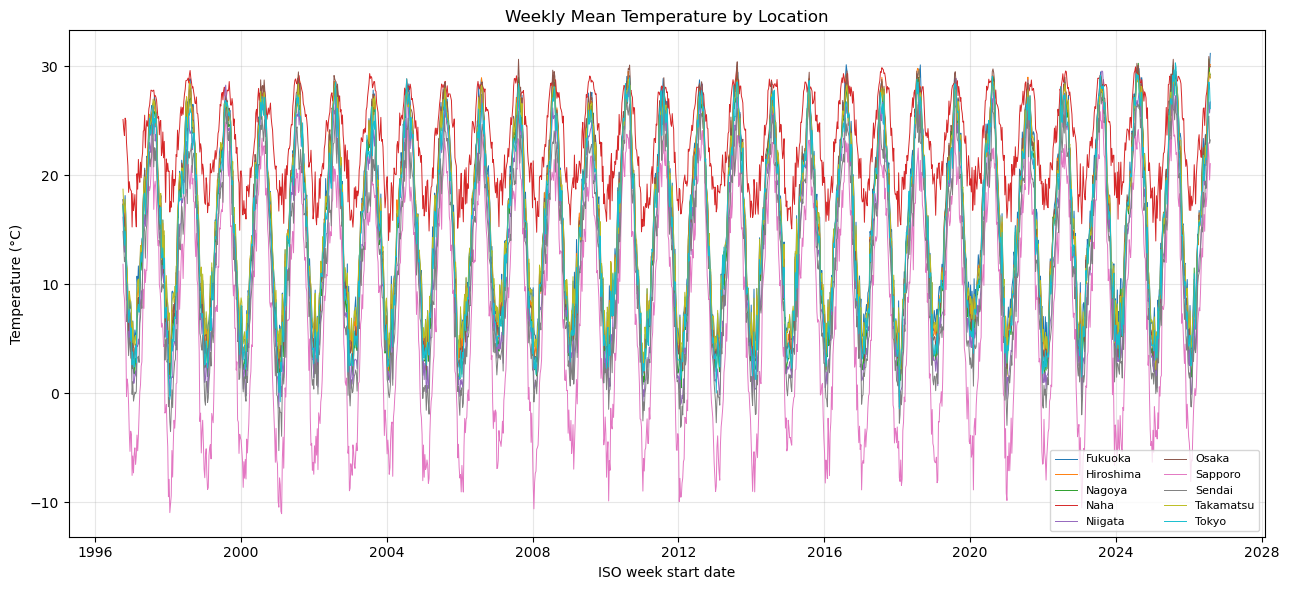

In [40]:
fig, ax = plt.subplots(figsize=(13, 6))
for location, location_data in df_weather_weekly.groupby("location"):
    ax.plot(
        location_data["ISO_WEEKSTARTDATE"],
        location_data["weekly_mean_temperature"],
        linewidth=0.7,
        label=location,
    )

ax.set_title("Weekly Mean Temperature by Location")
ax.set_xlabel("ISO week start date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# Stage 7 — Create the Multi-Location National Temperature Proxy

The location-level weekly data are combined into one national-level temperature proxy.

## 1. National Proxy Definition

FluNet provides national-level influenza data. The weather data therefore use an equal-weight average across ten representative locations.

This variable is a multi-location temperature proxy. It is not an official national average temperature for Japan. Population weighting is not used.

## 2. Check Location Availability by Week

The proxy is valid only when all ten locations have complete weekly data.

In [41]:
EXPECTED_LOCATIONS = locations_master["location"].nunique()

weekly_location_availability = df_weather_weekly.groupby(
    ["ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE"], as_index=False
).agg(
    location_count=("location", "nunique"),
    complete_location_count=("complete_week", "sum"),
)
weekly_location_availability["national_proxy_complete"] = (
    weekly_location_availability["complete_location_count"]
    .eq(EXPECTED_LOCATIONS)
)

weekly_location_availability.head()

,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,location_count,complete_location_count,national_proxy_complete
0,1996,41,1996-10-07,10,10,True
1,1996,42,1996-10-14,10,10,True
2,1996,43,1996-10-21,10,10,True
3,1996,44,1996-10-28,10,10,True
4,1996,45,1996-11-04,10,10,True


## 3. Calculate Weekly National Temperature Proxy

Each proxy value is the simple mean across the ten locations. National minimum and maximum are averages of location-level weekly minimum and maximum values, not the single extremes observed across Japan.

In [42]:
national_temperature_values = df_weather_weekly.groupby(
    ["ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE"], as_index=False
).agg(
    national_mean_temperature=("weekly_mean_temperature", "mean"),
    national_min_temperature=("weekly_min_temperature", "mean"),
    national_max_temperature=("weekly_max_temperature", "mean"),
)

df_weather_national = weekly_location_availability.merge(
    national_temperature_values,
    on=["ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE"],
    how="left",
)

national_temperature_columns = [
    "national_mean_temperature",
    "national_min_temperature",
    "national_max_temperature",
]
df_weather_national.loc[
    ~df_weather_national["national_proxy_complete"],
    national_temperature_columns,
] = pd.NA

## 4. Create National Proxy Dataset

The dataset keeps one row per ISO week and records how many locations support each value.

In [43]:
national_output_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
    "location_count", "complete_location_count", "national_proxy_complete",
    "national_mean_temperature", "national_min_temperature",
    "national_max_temperature",
]
df_weather_national = df_weather_national[national_output_columns].sort_values(
    "ISO_WEEKSTARTDATE"
).reset_index(drop=True)

national_overview = pd.DataFrame([{
    "Rows": len(df_weather_national),
    "Complete weeks": df_weather_national["national_proxy_complete"].sum(),
    "Incomplete weeks": (~df_weather_national["national_proxy_complete"]).sum(),
}])

display(national_overview)
display(df_weather_national.head(15))
display(df_weather_national.tail(15))

,Rows,Complete weeks,Incomplete weeks
0,1557,1557,0


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,location_count,complete_location_count,national_proxy_complete,national_mean_temperature,national_min_temperature,national_max_temperature
0,1996,41,1996-10-07,10,10,True,17.397143,11.96,23.54
1,1996,42,1996-10-14,10,10,True,15.781429,10.32,21.25
2,1996,43,1996-10-21,10,10,True,14.844286,7.93,22.22
3,1996,44,1996-10-28,10,10,True,15.942857,9.16,22.77
4,1996,45,1996-11-04,10,10,True,14.412857,7.33,20.47
5,1996,46,1996-11-11,10,10,True,10.325714,4.76,17.77
6,1996,47,1996-11-18,10,10,True,10.108571,5.12,16.05
7,1996,48,1996-11-25,10,10,True,8.170000,1.56,15.51
8,1996,49,1996-12-02,10,10,True,6.055714,0.65,14.66
9,1996,50,1996-12-09,10,10,True,7.492857,2.25,13.04


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,location_count,complete_location_count,national_proxy_complete,national_mean_temperature,national_min_temperature,national_max_temperature
1542,2026,18,2026-04-27,10,10,True,15.550000,9.47,22.62
1543,2026,19,2026-05-04,10,10,True,16.390000,9.32,23.02
1544,2026,20,2026-05-11,10,10,True,18.311429,11.69,25.59
1545,2026,21,2026-05-18,10,10,True,19.484286,13.32,26.53
1546,2026,22,2026-05-25,10,10,True,21.374286,15.15,27.13
1547,2026,23,2026-06-01,10,10,True,20.651429,16.58,27.74
1548,2026,24,2026-06-08,10,10,True,20.272857,14.89,25.80
1549,2026,25,2026-06-15,10,10,True,22.318571,17.21,27.26
1550,2026,26,2026-06-22,10,10,True,21.298571,17.37,26.06
1551,2026,27,2026-06-29,10,10,True,22.955714,19.09,27.44


## 5. Save National Proxy

The national proxy is saved before temperature change is calculated.

In [44]:
NATIONAL_PROXY_PATH = OPENMETEO_DIR / "openmeteo_weekly_national_proxy.csv"
df_weather_national.to_csv(NATIONAL_PROXY_PATH, index=False)
print(NATIONAL_PROXY_PATH)

dataset/openmeteo/openmeteo_weekly_national_proxy.csv


## 6. Audit National Proxy

This audit checks completeness, missing values, ranges, and temperature order.

In [45]:
national_temperature_order_violation = ~(
    (df_weather_national["national_min_temperature"] <= df_weather_national["national_mean_temperature"])
    & (df_weather_national["national_mean_temperature"] <= df_weather_national["national_max_temperature"])
)
national_temperature_order_violation &= df_weather_national[
    national_temperature_columns
].notna().all(axis=1)

national_proxy_audit = pd.DataFrame([{
    "total_weeks": len(df_weather_national),
    "complete_proxy_weeks": df_weather_national["national_proxy_complete"].sum(),
    "incomplete_proxy_weeks": (~df_weather_national["national_proxy_complete"]).sum(),
    "missing_national_mean": df_weather_national["national_mean_temperature"].isna().sum(),
    "missing_national_min": df_weather_national["national_min_temperature"].isna().sum(),
    "missing_national_max": df_weather_national["national_max_temperature"].isna().sum(),
    "minimum_national_mean": df_weather_national["national_mean_temperature"].min(),
    "maximum_national_mean": df_weather_national["national_mean_temperature"].max(),
    "minimum_national_min": df_weather_national["national_min_temperature"].min(),
    "maximum_national_max": df_weather_national["national_max_temperature"].max(),
    "temperature_order_violations": national_temperature_order_violation.sum(),
}])
national_proxy_audit

,total_weeks,complete_proxy_weeks,incomplete_proxy_weeks,missing_national_mean,missing_national_min,missing_national_max,minimum_national_mean,maximum_national_mean,minimum_national_min,maximum_national_max,temperature_order_violations
0,1557,1557,0,0,0,0,0.961429,28.504286,-4.65,33.99,0


## 7. Save National Proxy Audit

The one-row audit file documents the national proxy quality checks.

In [46]:
NATIONAL_PROXY_AUDIT_PATH = (
    OPENMETEO_DIR / "openmeteo_weekly_national_proxy_audit.csv"
)
national_proxy_audit.to_csv(NATIONAL_PROXY_AUDIT_PATH, index=False)
print(NATIONAL_PROXY_AUDIT_PATH)

dataset/openmeteo/openmeteo_weekly_national_proxy_audit.csv


## 8. Visualize National Temperature Proxy

This unsmoothed plot is a visual continuity check. Influenza data are not added here.

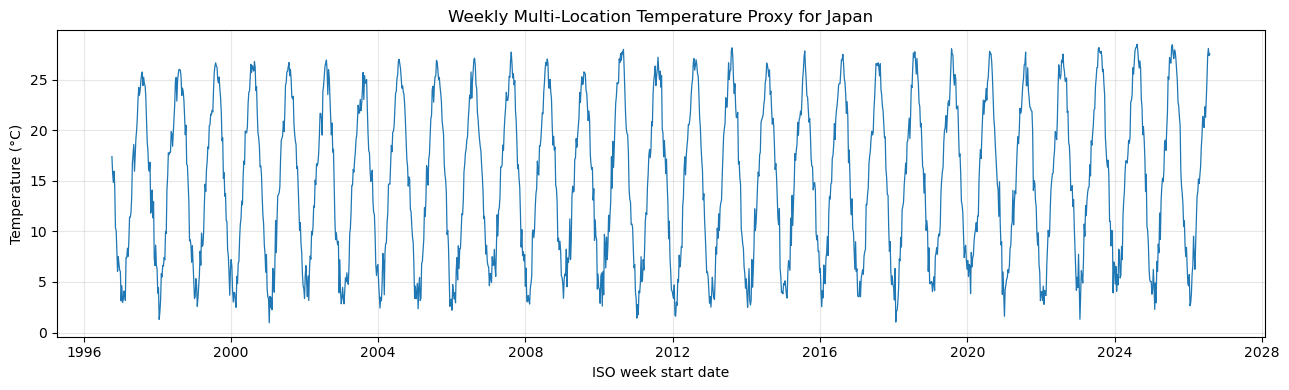

In [47]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    df_weather_national["ISO_WEEKSTARTDATE"],
    df_weather_national["national_mean_temperature"],
    linewidth=0.9,
)
ax.set_title("Weekly Multi-Location Temperature Proxy for Japan")
ax.set_xlabel("ISO week start date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Stage 8 — Calculate Week-to-Week Temperature Change

The national mean temperature is converted into a simple consecutive-week change feature.

## 1. Temperature Change Definition

Week-to-week temperature change is:

$$\Delta T = T(t) - T(t-1)$$

A negative value means temperature decreased. A positive value means temperature increased. No low/high groups are created.

## 2. Verify Consecutive Weeks Before Calculating Change

Temperature change is calculated only when week starts are seven days apart and both national mean temperatures are available.

In [48]:
df_weather_features = df_weather_national.sort_values(
    "ISO_WEEKSTARTDATE"
).copy()

df_weather_features["days_from_previous_week"] = (
    df_weather_features["ISO_WEEKSTARTDATE"].diff().dt.days
)
previous_temperature = df_weather_features["national_mean_temperature"].shift(1)

valid_temperature_change = (
    df_weather_features["days_from_previous_week"].eq(7)
    & df_weather_features["national_mean_temperature"].notna()
    & previous_temperature.notna()
)

df_weather_features["weekly_temperature_change"] = pd.NA
df_weather_features.loc[
    valid_temperature_change, "weekly_temperature_change"
] = (
    df_weather_features.loc[valid_temperature_change, "national_mean_temperature"]
    - previous_temperature.loc[valid_temperature_change]
)
df_weather_features["weekly_temperature_change"] = pd.to_numeric(
    df_weather_features["weekly_temperature_change"]
)

## 3. Create Temperature Feature Dataset

The feature dataset retains the national proxy, coverage information, and consecutive-week temperature change.

In [49]:
temperature_feature_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
    "national_mean_temperature", "national_min_temperature",
    "national_max_temperature", "weekly_temperature_change",
    "location_count", "complete_location_count", "national_proxy_complete",
]
df_weather_features = df_weather_features[
    temperature_feature_columns
].reset_index(drop=True)
df_weather_features.head(10)

,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,national_mean_temperature,national_min_temperature,national_max_temperature,weekly_temperature_change,location_count,complete_location_count,national_proxy_complete
0,1996,41,1996-10-07,17.397143,11.96,23.54,NaN,10,10,True
1,1996,42,1996-10-14,15.781429,10.32,21.25,-1.615714,10,10,True
2,1996,43,1996-10-21,14.844286,7.93,22.22,-0.937143,10,10,True
3,1996,44,1996-10-28,15.942857,9.16,22.77,1.098571,10,10,True
4,1996,45,1996-11-04,14.412857,7.33,20.47,-1.530000,10,10,True
5,1996,46,1996-11-11,10.325714,4.76,17.77,-4.087143,10,10,True
6,1996,47,1996-11-18,10.108571,5.12,16.05,-0.217143,10,10,True
7,1996,48,1996-11-25,8.170000,1.56,15.51,-1.938571,10,10,True
8,1996,49,1996-12-02,6.055714,0.65,14.66,-2.114286,10,10,True
9,1996,50,1996-12-09,7.492857,2.25,13.04,1.437143,10,10,True


## 4. Audit Temperature Change

The summary and extreme values are descriptive data checks only. They are not interpreted as influenza-related events.

In [50]:
temperature_change = df_weather_features["weekly_temperature_change"]
temperature_change_audit = pd.DataFrame([{
    "Total rows": len(df_weather_features),
    "Available changes": temperature_change.notna().sum(),
    "Missing changes": temperature_change.isna().sum(),
    "Minimum change": temperature_change.min(),
    "Maximum change": temperature_change.max(),
    "Mean change": temperature_change.mean(),
    "Median change": temperature_change.median(),
}])
temperature_change_audit

,Total rows,Available changes,Missing changes,Minimum change,Maximum change,Mean change,Median change
0,1557,1556,1,-6.122857,5.974286,0.00652,0.02


In [51]:
change_display_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
    "national_mean_temperature", "weekly_temperature_change",
]

largest_decreases = df_weather_features.nsmallest(
    10, "weekly_temperature_change"
)[change_display_columns]
largest_increases = df_weather_features.nlargest(
    10, "weekly_temperature_change"
)[change_display_columns]

print("Largest temperature decreases")
display(largest_decreases)
print("Largest temperature increases")
display(largest_increases)

Largest temperature decreases


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,national_mean_temperature,weekly_temperature_change
1419,2023,51,2023-12-18,3.915714,-6.122857
947,2014,49,2014-12-01,6.394286,-5.871429
1306,2021,42,2021-10-18,14.062857,-5.788571
60,1997,49,1997-12-01,7.317143,-5.618571
780,2011,38,2011-09-19,20.108571,-5.310000
1111,2018,4,2018-01-22,1.031429,-5.297143
1262,2020,51,2020-12-14,3.771429,-5.192857
1467,2024,47,2024-11-18,10.468571,-5.191429
888,2013,42,2013-10-14,16.667143,-5.104286
684,2009,47,2009-11-16,9.112857,-5.101429


Largest temperature increases


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,national_mean_temperature,weekly_temperature_change
698,2010,8,2010-02-22,9.704286,5.974286
962,2015,12,2015-03-16,11.310000,5.161429
964,2015,14,2015-03-30,13.555714,4.935714
710,2010,20,2010-05-17,18.891429,4.617143
1069,2017,14,2017-04-03,12.672857,4.471429
708,2010,18,2010-05-03,17.384286,4.418571
652,2009,15,2009-04-06,13.360000,4.390000
78,1998,15,1998-04-06,14.127143,4.328571
232,2001,12,2001-03-19,11.075714,4.317143
299,2002,27,2002-07-01,23.831429,4.310000


## 5. Save Temperature Feature Dataset

The weekly feature dataset is saved before merging with FluNet.

In [52]:
TEMPERATURE_FEATURE_PATH = (
    OPENMETEO_DIR / "openmeteo_weekly_temperature_features.csv"
)
df_weather_features.to_csv(TEMPERATURE_FEATURE_PATH, index=False)
print(TEMPERATURE_FEATURE_PATH)

dataset/openmeteo/openmeteo_weekly_temperature_features.csv


# Stage 9 — Merge Weather Data with FluNet

The national weekly weather features are aligned with the national weekly FluNet records.

## 1. Prepare FluNet Dataset

Weekly weather data are merged with FluNet using the same ISO week start date. The FluNet source file is not modified.

In [53]:
df_flunet = pd.read_csv(FLUNET_DATA_PATH)
df_flunet["ISO_WEEKSTARTDATE"] = pd.to_datetime(
    df_flunet["ISO_WEEKSTARTDATE"]
)

flunet_merge_overview = pd.DataFrame([{
    "Rows": len(df_flunet),
    "Minimum date": df_flunet["ISO_WEEKSTARTDATE"].min(),
    "Maximum date": df_flunet["ISO_WEEKSTARTDATE"].max(),
    "Unique weeks": df_flunet["ISO_WEEKSTARTDATE"].nunique(),
}])
flunet_merge_overview

,Rows,Minimum date,Maximum date,Unique weeks
0,1522,1996-10-07,2026-08-03,1522


## 2. Validate Merge Key

Both national weekly datasets must have one row per `ISO_WEEKSTARTDATE` before the merge.

In [54]:
merge_key_audit = pd.DataFrame([
    {
        "Dataset": "FluNet",
        "Rows": len(df_flunet),
        "Unique ISO_WEEKSTARTDATE": df_flunet["ISO_WEEKSTARTDATE"].nunique(),
        "Duplicate ISO_WEEKSTARTDATE": df_flunet.duplicated(
            "ISO_WEEKSTARTDATE"
        ).sum(),
    },
    {
        "Dataset": "National weather",
        "Rows": len(df_weather_features),
        "Unique ISO_WEEKSTARTDATE": df_weather_features[
            "ISO_WEEKSTARTDATE"
        ].nunique(),
        "Duplicate ISO_WEEKSTARTDATE": df_weather_features.duplicated(
            "ISO_WEEKSTARTDATE"
        ).sum(),
    },
])
display(merge_key_audit)

flunet_duplicate_weeks = df_flunet.loc[
    df_flunet.duplicated("ISO_WEEKSTARTDATE", keep=False)
]
weather_duplicate_weeks = df_weather_features.loc[
    df_weather_features.duplicated("ISO_WEEKSTARTDATE", keep=False)
]
display(flunet_duplicate_weeks)
display(weather_duplicate_weeks)

assert flunet_duplicate_weeks.empty and weather_duplicate_weeks.empty

,Dataset,Rows,Unique ISO_WEEKSTARTDATE,Duplicate ISO_WEEKSTARTDATE
0,FluNet,1522,1522,0
1,National weather,1557,1557,0


,WHOREGION,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2,HEMISPHERE,FLUSEASON,ORIGIN_SOURCE,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,ISOYW,INF_A,INF_B,INF_ALL,SPEC_PROCESSED_NB,INF_NEGATIVE,positive_specimen_count,positive_count_source,positivity_rate_percent


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,national_mean_temperature,national_min_temperature,national_max_temperature,weekly_temperature_change,location_count,complete_location_count,national_proxy_complete


## 3. Compare Weekly Coverage Before Merge

Week-start dates are compared before merging. Unmatched dates are displayed and not removed automatically.

In [55]:
flunet_week_dates = set(df_flunet["ISO_WEEKSTARTDATE"])
weather_week_dates = set(df_weather_features["ISO_WEEKSTARTDATE"])

flunet_missing_weather = sorted(flunet_week_dates - weather_week_dates)
weather_not_in_flunet = sorted(weather_week_dates - flunet_week_dates)

pre_merge_coverage = pd.DataFrame([{
    "FluNet weeks": len(flunet_week_dates),
    "Weather weeks": len(weather_week_dates),
    "Weeks in both": len(flunet_week_dates & weather_week_dates),
    "FluNet weeks missing weather": len(flunet_missing_weather),
    "Weather weeks not in FluNet": len(weather_not_in_flunet),
}])
display(pre_merge_coverage)
display(pd.DataFrame({"FluNet week missing weather": flunet_missing_weather}))
display(pd.DataFrame({"Weather week not in FluNet": weather_not_in_flunet}))

,FluNet weeks,Weather weeks,Weeks in both,FluNet weeks missing weather,Weather weeks not in FluNet
0,1522,1557,1522,0,35


,FluNet week missing weather


,Weather week not in FluNet
0,1997-04-14
1,1997-04-28
2,1997-05-05
3,1997-05-12
4,1997-05-19
5,1997-05-26
6,1997-06-02
7,1997-06-09
8,1997-06-16
9,1997-06-23


## 4. Merge FluNet and Weather

FluNet remains the main dataset. Only required weather fields and temporary ISO validation fields are added.

In [56]:
weather_for_merge = df_weather_features.rename(columns={
    "ISO_YEAR": "weather_ISO_YEAR",
    "ISO_WEEK": "weather_ISO_WEEK",
})

weather_merge_columns = [
    "ISO_WEEKSTARTDATE", "weather_ISO_YEAR", "weather_ISO_WEEK",
    "national_mean_temperature", "national_min_temperature",
    "national_max_temperature", "weekly_temperature_change",
    "location_count", "complete_location_count", "national_proxy_complete",
]

df_analysis_ready = df_flunet.merge(
    weather_for_merge[weather_merge_columns],
    on="ISO_WEEKSTARTDATE",
    how="left",
    validate="one_to_one",
)

## 6. Validate ISO Year and Week Alignment

Weather ISO year and week must match the FluNet values. Temporary validation columns are removed after the check.

In [57]:
matched_weather = df_analysis_ready["weather_ISO_YEAR"].notna()
iso_year_mismatches = (
    df_analysis_ready.loc[matched_weather, "ISO_YEAR"]
    != df_analysis_ready.loc[matched_weather, "weather_ISO_YEAR"]
).sum()
iso_week_mismatches = (
    df_analysis_ready.loc[matched_weather, "ISO_WEEK"]
    != df_analysis_ready.loc[matched_weather, "weather_ISO_WEEK"]
).sum()

alignment_audit = pd.DataFrame([{
    "ISO year mismatches": iso_year_mismatches,
    "ISO week mismatches": iso_week_mismatches,
}])
display(alignment_audit)

df_analysis_ready = df_analysis_ready.drop(
    columns=["weather_ISO_YEAR", "weather_ISO_WEEK"]
)

,ISO year mismatches,ISO week mismatches
0,0,0


## 7. Audit Final Merged Dataset

The merged dataset is checked for duplicate weeks, date coverage, missing analysis fields, and national proxy completeness.

In [58]:
final_dataset_audit = pd.DataFrame([{
    "Total rows": len(df_analysis_ready),
    "Unique weeks": df_analysis_ready["ISO_WEEKSTARTDATE"].nunique(),
    "Duplicate weeks": df_analysis_ready.duplicated("ISO_WEEKSTARTDATE").sum(),
    "Minimum date": df_analysis_ready["ISO_WEEKSTARTDATE"].min(),
    "Maximum date": df_analysis_ready["ISO_WEEKSTARTDATE"].max(),
    "Missing positive count": df_analysis_ready["positive_specimen_count"].isna().sum(),
    "Missing national mean": df_analysis_ready["national_mean_temperature"].isna().sum(),
    "Missing national min": df_analysis_ready["national_min_temperature"].isna().sum(),
    "Missing national max": df_analysis_ready["national_max_temperature"].isna().sum(),
    "Missing temperature change": df_analysis_ready["weekly_temperature_change"].isna().sum(),
    "Complete national proxy weeks": df_analysis_ready["national_proxy_complete"].eq(True).sum(),
    "Incomplete national proxy weeks": df_analysis_ready["national_proxy_complete"].ne(True).sum(),
}])
final_dataset_audit

,Total rows,Unique weeks,Duplicate weeks,Minimum date,Maximum date,Missing positive count,Missing national mean,Missing national min,Missing national max,Missing temperature change,Complete national proxy weeks,Incomplete national proxy weeks
0,1522,1522,0,1996-10-07,2026-08-03,17,0,0,0,1,1522,0


## 8. Preview Final Analysis-Ready Structure

The preview shows the main influenza and weather variables aligned to the same ISO week.

In [59]:
analysis_preview_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
    "positive_specimen_count", "positive_count_source",
    "national_mean_temperature", "national_min_temperature",
    "national_max_temperature", "weekly_temperature_change",
    "complete_location_count", "national_proxy_complete",
]

display(df_analysis_ready[analysis_preview_columns].head(15))
display(df_analysis_ready[analysis_preview_columns].tail(15))

,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,positive_specimen_count,positive_count_source,national_mean_temperature,national_min_temperature,national_max_temperature,weekly_temperature_change,complete_location_count,national_proxy_complete
0,1996,41,1996-10-07,1.0,INF_ALL,17.397143,11.96,23.54,NaN,10,True
1,1996,42,1996-10-14,2.0,INF_ALL,15.781429,10.32,21.25,-1.615714,10,True
2,1996,43,1996-10-21,1.0,INF_ALL,14.844286,7.93,22.22,-0.937143,10,True
3,1996,44,1996-10-28,4.0,INF_ALL,15.942857,9.16,22.77,1.098571,10,True
4,1996,45,1996-11-04,11.0,INF_ALL,14.412857,7.33,20.47,-1.530000,10,True
5,1996,46,1996-11-11,12.0,INF_ALL,10.325714,4.76,17.77,-4.087143,10,True
6,1996,47,1996-11-18,26.0,INF_ALL,10.108571,5.12,16.05,-0.217143,10,True
7,1996,48,1996-11-25,65.0,INF_ALL,8.170000,1.56,15.51,-1.938571,10,True
8,1996,49,1996-12-02,194.0,INF_ALL,6.055714,0.65,14.66,-2.114286,10,True
9,1996,50,1996-12-09,436.0,INF_ALL,7.492857,2.25,13.04,1.437143,10,True


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,positive_specimen_count,positive_count_source,national_mean_temperature,national_min_temperature,national_max_temperature,weekly_temperature_change,complete_location_count,national_proxy_complete
1507,2026,18,2026-04-27,10.0,INF_ALL,15.550000,9.47,22.62,0.820000,10,True
1508,2026,19,2026-05-04,3.0,INF_ALL,16.390000,9.32,23.02,0.840000,10,True
1509,2026,20,2026-05-11,6.0,INF_ALL,18.311429,11.69,25.59,1.921429,10,True
1510,2026,21,2026-05-18,7.0,INF_ALL,19.484286,13.32,26.53,1.172857,10,True
1511,2026,22,2026-05-25,3.0,INF_ALL,21.374286,15.15,27.13,1.890000,10,True
1512,2026,23,2026-06-01,7.0,INF_ALL,20.651429,16.58,27.74,-0.722857,10,True
1513,2026,24,2026-06-08,1.0,INF_ALL,20.272857,14.89,25.80,-0.378571,10,True
1514,2026,25,2026-06-15,1.0,INF_ALL,22.318571,17.21,27.26,2.045714,10,True
1515,2026,26,2026-06-22,3.0,INF_ALL,21.298571,17.37,26.06,-1.020000,10,True
1516,2026,27,2026-06-29,1.0,INF_ALL,22.955714,19.09,27.44,1.657143,10,True


## 9. Save Final Merged Dataset

The aligned weekly dataset is saved as a new file. The FluNet source file is not overwritten.

In [60]:
FINAL_ANALYSIS_PATH = Path(
    "dataset/japan_influenza_temperature_analysis_ready.csv"
)
df_analysis_ready.to_csv(FINAL_ANALYSIS_PATH, index=False)
print(FINAL_ANALYSIS_PATH)

dataset/japan_influenza_temperature_analysis_ready.csv


## 10. Simple Combined Data Preview

The two panels confirm that weekly temperature and influenza counts share the same time axis. They are not smoothed, standardized, or statistically compared.

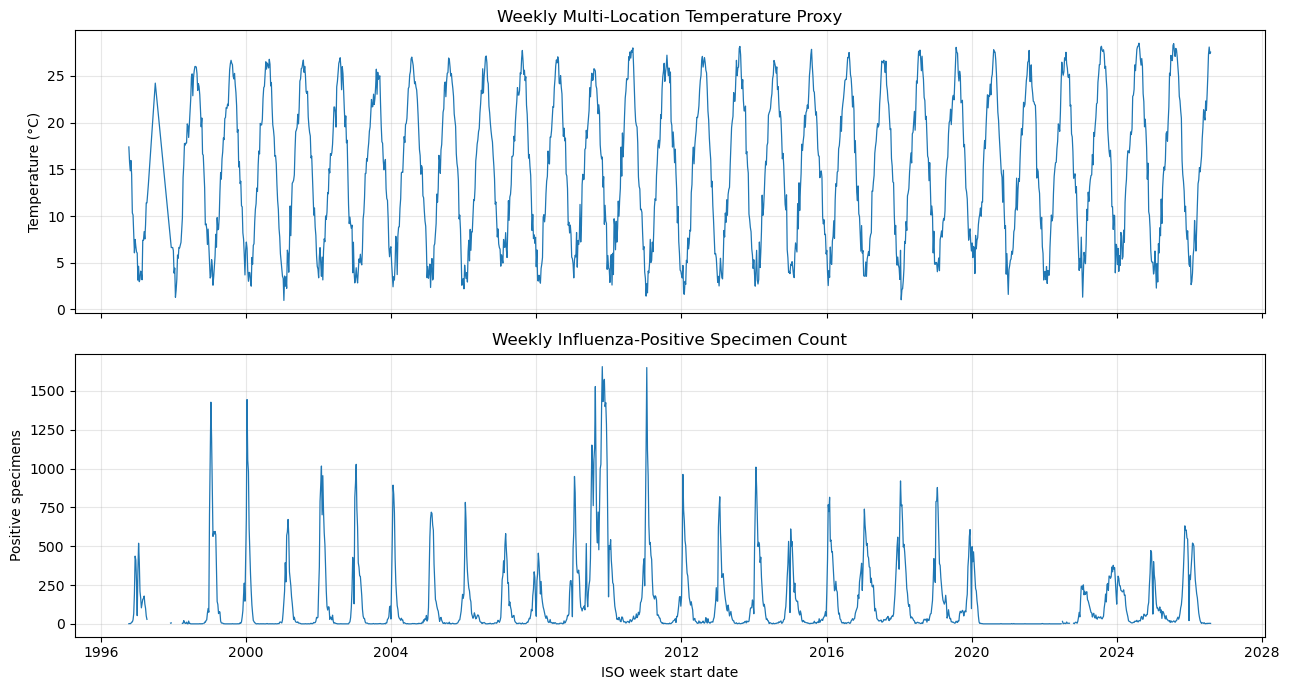

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(
    df_analysis_ready["ISO_WEEKSTARTDATE"],
    df_analysis_ready["national_mean_temperature"],
    linewidth=0.9,
)
axes[0].set_title("Weekly Multi-Location Temperature Proxy")
axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    df_analysis_ready["ISO_WEEKSTARTDATE"],
    df_analysis_ready["positive_specimen_count"],
    linewidth=0.9,
)
axes[1].set_title("Weekly Influenza-Positive Specimen Count")
axes[1].set_xlabel("ISO week start date")
axes[1].set_ylabel("Positive specimens")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Weekly Data Preparation Summary

- Daily weather data were converted to Monday–Sunday ISO weeks.
- Each location-week required seven complete daily observations.
- Weekly coverage, duplicates, missing values, and temperature order were audited.
- An equal-weight proxy was calculated from ten representative locations.
- The proxy was calculated only when all ten locations were complete.
- Week-to-week national mean temperature change was calculated only for consecutive weeks.
- Weather and FluNet data were aligned using `ISO_WEEKSTARTDATE`.
- The merged weekly dataset was saved for later analysis.

# 64. Final Dataset Definition

### Influenza activity — `positive_specimen_count`

Weekly number of influenza-positive specimens reported through FluNet surveillance.

### Weekly mean temperature — `national_mean_temperature`

Equal-weight mean of weekly mean temperature from the ten selected locations.

### Weekly minimum temperature proxy — `national_min_temperature`

Equal-weight mean of the location-level weekly minimum temperatures.

### Weekly maximum temperature proxy — `national_max_temperature`

Equal-weight mean of the location-level weekly maximum temperatures.

### Temperature change — `weekly_temperature_change`

Current national mean temperature minus the previous consecutive week's value.

The national temperature variables are multi-location proxies. They are not official national average temperatures for Japan.